### Key Point Pembeda Jeruk

1. **Jeruk Siam**
    - Diameter & Berat: kecil–sedang (5–7 cm, 80–120 g)
    - Kulit: tipis, agak longgar, gampang dikupas
    - Rasa: manis segar tapi tidak terlalu pekat (kadar gula 9–11%)
    - Ciri khas: sering buat perasan, warnanya agak pucat
2. **Jeruk Pontianak (kadang disebut jeruk manis Pontianak)**
    - Diameter & Berat: sedang–besar (7–9 cm, 140–190 g)
    - Kulit: agak tebal (3–4 mm), melekat kuat
    - Rasa: manis kuat (kadar gula 12–13%)
    - Ciri khas: sering dijadikan jeruk meja, lebih "berisi" dan berair
3. **Jeruk Mandarin**
    - Diameter & Berat: kecil–sedang (6–7.5 cm, 100–130 g)
    - Kulit: sangat tipis & longgar, mudah dikupas (paling gampang di antara ketiga jenis ini)
    - Rasa: sangat manis, kadar gula paling tinggi (12–13%), aromanya harum khas
    - Ciri khas: buahnya “imut-imut” dan sering untuk jeruk Imlek

In [32]:
import pandas as pd

df = pd.read_csv("dataset_jeruk.csv")
df

,diameter,berat,tebal_kulit,kadar_gula,jenis
0,5.5,80,2.0,9.5,siam
1,6.0,95,2.5,10.0,siam
2,6.5,110,2.3,10.5,siam
3,7.0,130,2.8,11.0,siam
4,5.8,85,2.2,9.8,siam
5,7.2,140,3.0,11.5,pontianak
6,7.5,160,3.5,12.0,pontianak
7,8.0,175,3.2,12.5,pontianak
8,8.3,190,3.8,12.8,pontianak
9,7.8,165,3.4,12.2,pontianak


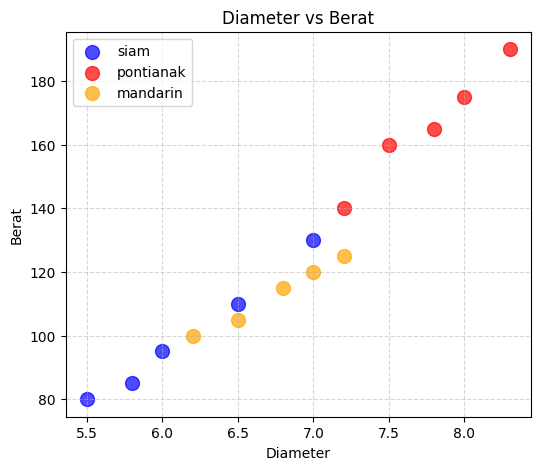

In [33]:
import matplotlib.pyplot as plt

siam = df[df["jenis"]=="siam"]
pontianak = df[df["jenis"]=="pontianak"]
mandarin = df[df["jenis"]=="mandarin"]

plt.figure(figsize=(6,5))

plt.scatter(siam["diameter"], siam["berat"], color="blue", s=100, alpha=0.7, label="siam")
plt.scatter(pontianak["diameter"], pontianak["berat"], color="red", s=100, alpha=0.7, label="pontianak")
plt.scatter(mandarin["diameter"], mandarin["berat"], color="orange", s=100, alpha=0.7, label="mandarin")

plt.xlabel("Diameter")
plt.ylabel("Berat")
plt.title("Diameter vs Berat")
plt.legend()
plt.grid(True,linestyle="--",alpha=0.5)
plt.show()

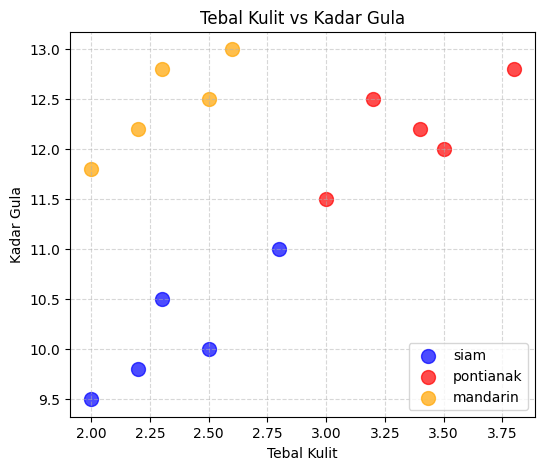

In [34]:
import matplotlib.pyplot as plt

siam = df[df["jenis"]=="siam"]
pontianak = df[df["jenis"]=="pontianak"]
mandarin = df[df["jenis"]=="mandarin"]

plt.figure(figsize=(6,5))

plt.scatter(siam["tebal_kulit"], siam["kadar_gula"], color="blue", s=100, alpha=0.7, label="siam")
plt.scatter(pontianak["tebal_kulit"], pontianak["kadar_gula"], color="red", s=100, alpha=0.7, label="pontianak")
plt.scatter(mandarin["tebal_kulit"], mandarin["kadar_gula"], color="orange", s=100, alpha=0.7, label="mandarin")

plt.xlabel("Tebal Kulit")
plt.ylabel("Kadar Gula")
plt.title("Tebal Kulit vs Kadar Gula")
plt.legend()
plt.grid(True,linestyle="--",alpha=0.5)
plt.show()

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.preprocessing import StandardScaler

X = df[["diameter","berat","tebal_kulit","kadar_gula"]]
y = df["jenis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)
print("Accuracy :", accuracy_score(y_pred, y_test))

Accuracy : 1.0


In [36]:
data_baru = pd.DataFrame([[7,90,3,10]], columns=["diameter","berat","tebal_kulit","kadar_gula"])
data_baru_scaled = scaler.transform(data_baru)

print(model.classes_)
print(model.predict_proba(data_baru_scaled)[0])
print("Prediksi : ", model.predict(data_baru_scaled)[0])

['mandarin' 'pontianak' 'siam']
[0.04108128 0.0860817  0.87283702]
Prediksi :  siam


In [37]:
import joblib

joblib.dump(model, "model_klasifikasi_jeruk.joblib")
joblib.dump(scaler, "scaler_klasifikasi_jeruk.joblib")

['scaler_klasifikasi_jeruk.joblib']

In [38]:
# coba simulasi load model dan load scaler untuk prediksi data baru
import pandas as pd
import joblib

model = joblib.load("model_klasifikasi_jeruk.joblib")
scaler = joblib.load("scaler_klasifikasi_jeruk.joblib")

data_lain = pd.DataFrame([[8.5,112,2,17]], columns=["diameter","berat","tebal_kulit","kadar_gula"])
data_lain_scaled = scaler.transform(data_lain)

hasil = model.predict(data_lain_scaled)[0]
presentase = max(model.predict_proba(data_lain_scaled)[0])

print(f"Model memprediksi data tersebut sebagai jeruk {hasil} dengan tingkat keyakinan {presentase*100:.2f}%")

Model memprediksi data tersebut sebagai jeruk mandarin dengan tingkat keyakinan 99.78%
